# Memory-Efficient Instance Segmentation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow/supervision/blob/develop/docs/notebooks/compact-mask-sam3.ipynb)

**supervision** is a set of reusable tools for computer vision.
Two headlining changes in 0.28.0:

1. **`sv.Detections.from_sam3`** -- first-class support for SAM3 (Segment
   Anything Model 3) inference responses. supervision now parses both the
   PCS (prompt-controlled segmentation) and PVS (point-video segmentation)
   output formats directly into a `sv.Detections` object.

2. **`sv.CompactMask`** -- instance masks stored as RLE-encoded bounding-box
   crops instead of full-resolution bitmaps. Any segmentation model --
   RF-DETR Seg, SAM3, YOLO-Seg -- can feed into CompactMask. Memory drops
   10-100x without changing the API anywhere in supervision.

**Story**: run RF-DETR Seg on a real image, visualise the masks, then convert
to CompactMask and watch the memory footprint collapse.

**Sections:**
1. [Install](#1-install)
2. [Download sample image](#2-download-sample-image)
3. [RF-DETR Seg -- instance segmentation](#3-rf-detr-seg)
4. [CompactMask -- memory-efficient storage](#4-compactmask)
5. [SAM3 -- text-prompted segmentation](#5-sam3)
6. [Other notable changes in 0.28.0](#6-other-notable-changes)
7. [Next steps](#7-next-steps)

## 1. Install

In [ ]:
!pip install -q 'supervision==0.28.0' 'rfdetr' 'inference-sdk>=0.9' numpy matplotlib

## 2. Download sample image

`sv.ImageAssets` is new in 0.28.0 -- a counterpart to the existing
`sv.VideoAssets`. `download_assets` caches locally and returns the path.

[2026-04-30 23:36:55] [INFO] supervision.assets.downloader - Downloading people-walking.jpg assets


  0%|          | 0/342802 [00:00<?, ?it/s]

Image: people-walking.jpg
Resolution: 1920 x 1080


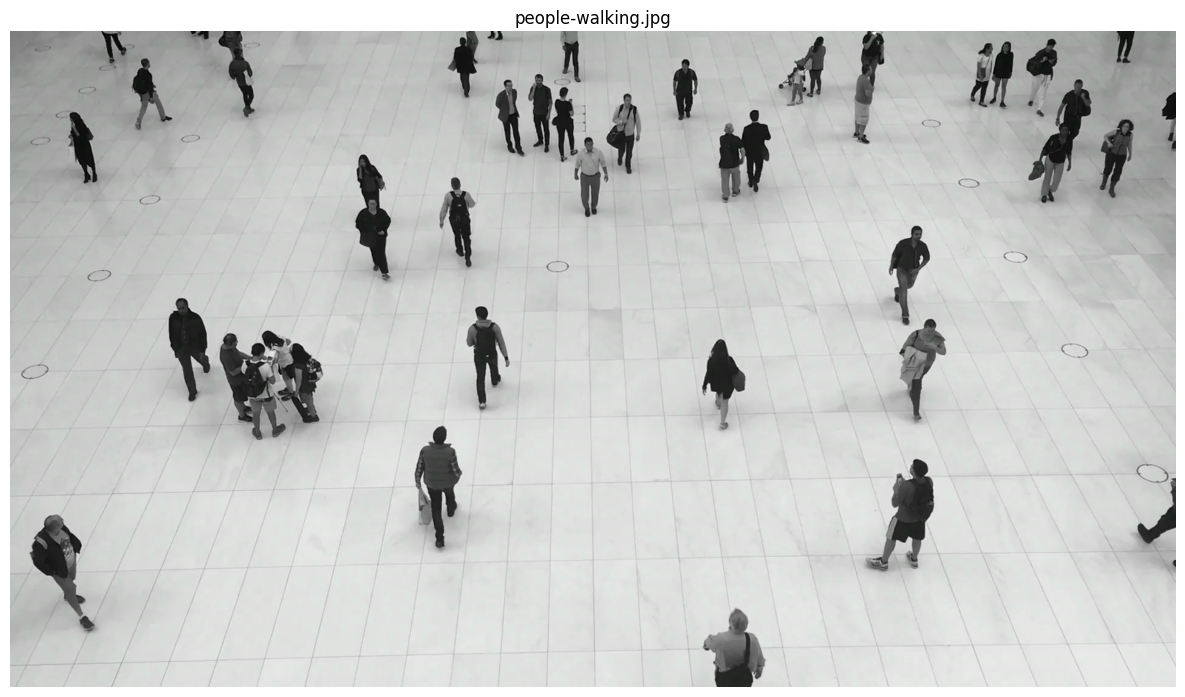

In [2]:
%matplotlib inline

import cv2
import matplotlib.pyplot as plt
import numpy as np

import supervision as sv
from supervision.assets import ImageAssets, download_assets

image_path = download_assets(ImageAssets.PEOPLE_WALKING)
print(f"Image: {image_path}")

image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
H, W = image_bgr.shape[:2]
print(f"Resolution: {W} x {H}")

plt.figure(figsize=(12, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("people-walking.jpg")
plt.tight_layout()
plt.show()

## 3. RF-DETR Seg

**RF-DETR** is a real-time transformer-based object detection model from Roboflow.
The `RFDETRSegSmall` variant adds an instance segmentation head -- it produces
one binary mask per detected instance alongside the bounding box.

Key facts for this demo:

- Pretrained on **COCO** (80 object categories) -- detects people, bags, cars, etc.
- Weights download automatically on first `RFDETRSegSmall()` call (~100 MB).
- `model.predict()` returns **`sv.Detections`** directly -- no converter needed.
  Masks are a `(N, H, W)` bool array attached as `detections.mask`.

In [ ]:
from rfdetr.detr import RFDETRSegSmall

model = RFDETRSegSmall()
model.optimize_for_inference()

# predict accepts a file path, PIL Image, or RGB numpy array
detections = model.predict(image_path, threshold=0.3)
if not isinstance(detections, sv.Detections):
    raise TypeError(f"Expected sv.Detections, got {type(detections).__name__}")

n_masks = 0 if detections.mask is None else len(detections.mask)
print(f"Detections: {len(detections)}  (with masks: {n_masks})")

### 3.1 COCO class names

COCO has 90 numeric class IDs; map them to readable names for annotation.

In [4]:
# Subset of COCO class names (IDs 0-based after RF-DETR's remapping).
COCO_NAMES: dict[int, str] = {
    0: "person",
    1: "bicycle",
    2: "car",
    3: "motorcycle",
    4: "airplane",
    5: "bus",
    6: "train",
    7: "truck",
    8: "boat",
    24: "backpack",
    25: "umbrella",
    26: "handbag",
    28: "suitcase",
    56: "chair",
    57: "couch",
    58: "potted plant",
    59: "bed",
    60: "dining table",
    62: "tv",
    63: "laptop",
    67: "cell phone",
    72: "refrigerator",
    74: "clock",
    76: "scissors",
}

labels = []
assert detections.class_id is not None
for cid, conf in zip(
    detections.class_id,
    detections.confidence
    if detections.confidence is not None
    else [None] * len(detections),
):
    name = COCO_NAMES.get(int(cid), f"cls_{cid}")
    labels.append(f"{name} {conf:.2f}" if conf is not None else name)

### 3.2 Visualise RF-DETR Seg output

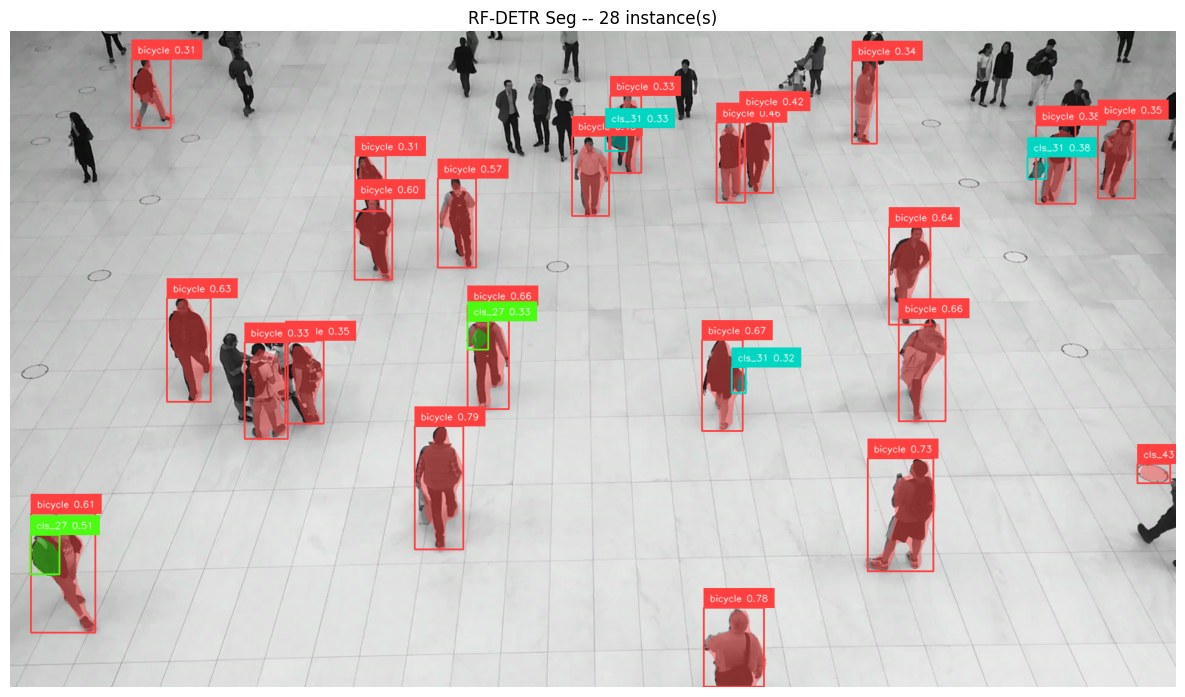

In [5]:
PALETTE = sv.ColorPalette.DEFAULT

annotated = image_bgr.copy()
annotated = sv.MaskAnnotator(color=PALETTE, opacity=0.45).annotate(
    annotated, detections
)
annotated = sv.BoxAnnotator(color=PALETTE, thickness=2).annotate(annotated, detections)
annotated = sv.LabelAnnotator(color=PALETTE, text_scale=0.5, text_thickness=1).annotate(
    annotated, detections, labels=labels
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"RF-DETR Seg -- {len(detections)} instance(s)")
plt.tight_layout()
plt.show()

## 4. CompactMask

RF-DETR Seg returns one full-resolution binary mask per detected instance.
On a 1280 x 720 image with 12 people that is:

`12 x 720 x 1280 x 1 byte = 11 MB`

Most of those pixels are background. The actual person silhouette fits in a
tight bounding box. `sv.CompactMask` stores **only the bounding-box crop**,
RLE-encoded:

- A 200 x 100 person crop: `~2.5 KB` instead of `900 KB`
- Drop-in replacement -- all annotators, filters, and `area` keep working

### 4.1 Measure dense mask footprint

In [6]:
from typing import Any

dense_bytes: int = 0
dense_mask: "np.ndarray[Any, np.dtype[np.bool_]] | None" = None

assert detections.mask is not None and isinstance(detections.mask, np.ndarray)

dense_mask = detections.mask
dense_bytes = dense_mask.nbytes
n_inst = len(dense_mask)
print(f"Instances:       {n_inst}")
print(f"Mask shape:      {dense_mask.shape}  (N x H x W, bool)")
print(f"Dense footprint: {dense_bytes / 1024:.1f} KB")
print(f"  = {n_inst} masks x {H} x {W} x 1 byte")

Instances:       28
Mask shape:      (28, 1080, 1920)  (N x H x W, bool)
Dense footprint: 56700.0 KB
  = 28 masks x 1080 x 1920 x 1 byte


### 4.2 Convert to CompactMask

In [7]:
compact: "sv.CompactMask | None" = None
crop_bytes: int = 0

assert dense_mask is not None
compact = sv.CompactMask.from_dense(
    masks=dense_mask,
    xyxy=detections.xyxy,
    image_shape=(H, W),
)

# Measure compact size via uncompressed crop booleans (upper bound; RLE < this).
crop_bytes = sum(compact.crop(i).nbytes for i in range(len(compact)))

print(f"Crop size (est.):   {crop_bytes / 1024:.1f} KB  (uncompressed crops)")
if crop_bytes > 0 and dense_bytes > 0:
    ratio = dense_bytes / crop_bytes
    print(f"Reduction factor:   {ratio:.1f}x  (before RLE compression)")

# Swap in CompactMask -- supervision uses it transparently from here on.
detections.mask = compact
print(f"\ndetections.mask type: {type(detections.mask).__name__}")

Crop size (est.):   236.8 KB  (uncompressed crops)
Reduction factor:   239.5x  (before RLE compression)

detections.mask type: CompactMask


### 4.3 Filtering by mask area

`compact.area` returns the true pixel count of each instance mask.
Filter out tiny detections (partial occlusions, image-edge artefacts).

In [8]:
large: sv.Detections = detections
large_labels: list[str] = labels

assert isinstance(detections.mask, sv.CompactMask)
areas = detections.mask.area
print(
    f"Mask areas (px): min={areas.min():.0f}  "
    f"mean={areas.mean():.0f}  max={areas.max():.0f}"
)

# Keep instances larger than 0.1% of the image.
min_area = 0.001 * H * W
keep_idx = np.where(areas > min_area)[0]
_filtered = detections[keep_idx]
if isinstance(_filtered, sv.Detections):
    large = _filtered
    large_labels = [labels[i] for i in keep_idx] if labels else []
print(f"\nInstances > {min_area:.0f} px: {len(large)}")

Mask areas (px): min=357  mean=4437  max=9291

Instances > 2074 px: 23


### 4.4 Annotate with CompactMask

Annotators call `.to_dense()` internally -- CompactMask is invisible to them.

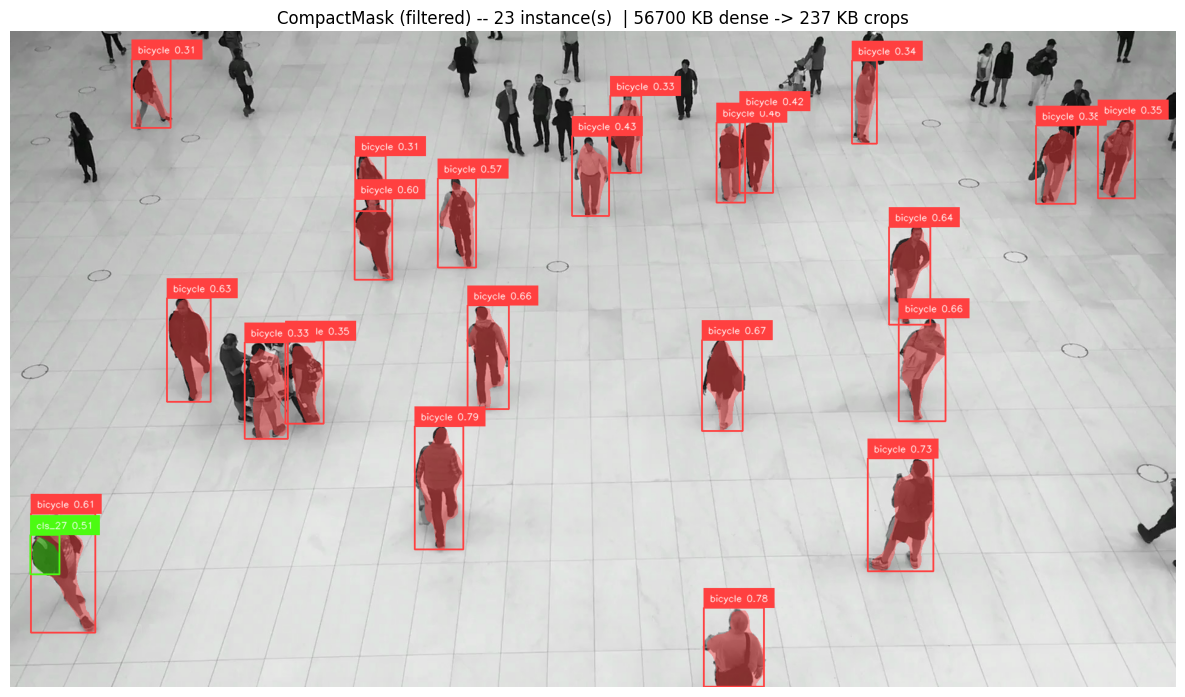

In [9]:
assert isinstance(detections.mask, sv.CompactMask) and dense_bytes > 0

annotated_compact = image_bgr.copy()
annotated_compact = sv.MaskAnnotator(color=PALETTE, opacity=0.45).annotate(
    annotated_compact, large
)
annotated_compact = sv.BoxAnnotator(color=PALETTE, thickness=2).annotate(
    annotated_compact, large
)
annotated_compact = sv.LabelAnnotator(
    color=PALETTE, text_scale=0.5, text_thickness=1
).annotate(annotated_compact, large, labels=large_labels)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated_compact, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(
    f"CompactMask (filtered) -- {len(large)} instance(s)  "
    f"| {dense_bytes / 1024:.0f} KB dense -> {crop_bytes / 1024:.0f} KB crops"
)
plt.tight_layout()
plt.show()

### 4.5 Per-instance crop

`compact.crop(i)` decodes only the bounding-box crop for instance `i` as a
`(H_crop, W_crop)` bool array -- no full mask materialised.

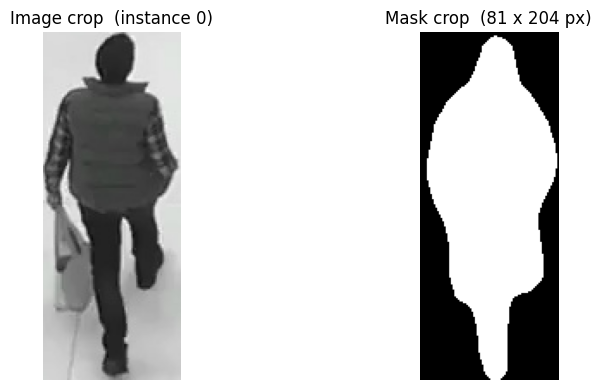

Full-res mask slot: 1080 x 1920 = 2025 KB
Compact crop:       204 x 81 = 16.1 KB


In [10]:
assert isinstance(detections.mask, sv.CompactMask) and len(detections) > 0

crop = detections.mask.crop(0)
bbox = detections.mask.bbox_xyxy[0].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_rgb[bbox[1] : bbox[3], bbox[0] : bbox[2]])
axes[0].set_title("Image crop  (instance 0)")
axes[0].axis("off")

axes[1].imshow(crop, cmap="gray")
axes[1].set_title(f"Mask crop  ({crop.shape[1]} x {crop.shape[0]} px)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

full_px = H * W
crop_kb = crop.nbytes / 1024
print(f"Full-res mask slot: {H} x {W} = {full_px / 1024:.0f} KB")
print(f"Compact crop:       {crop.shape[0]} x {crop.shape[1]} = {crop_kb:.1f} KB")

## 5. SAM3

`sv.Detections.from_sam3()` is the other headline in 0.28.0.
SAM3 segments objects by free-text prompts -- `"person"`, `"bag"`, any phrase.
supervision parses both the PCS and PVS response formats into a standard
`sv.Detections`, with `class_id` set to the prompt index.

This section runs only when `ROBOFLOW_API_KEY` is available.

In [11]:
import base64
import os
from typing import Optional

import requests

try:
    from google.colab import userdata  # type: ignore[import, unused-ignore]

    ROBOFLOW_API_KEY: str = userdata.get("ROBOFLOW_API_KEY") or ""
except Exception:
    ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "")

PROMPTS = ["person", "bag"]
sam3_detections: Optional[sv.Detections] = None

assert ROBOFLOW_API_KEY

with open(image_path, "rb") as _f:
    _img_b64 = base64.b64encode(_f.read()).decode("utf-8")

_response = requests.post(
    f"https://api.roboflow.com/inferenceproxy/seg-preview?api_key={ROBOFLOW_API_KEY}",
    json={
        "image": {"type": "base64", "value": _img_b64},
        "prompts": [{"type": "text", "text": p} for p in PROMPTS],
        "output_prob_thresh": 0.3,
    },
    headers={"Content-Type": "application/json"},
    timeout=60,
)
_response.raise_for_status()
sam3_result: dict[str, Any] = _response.json()
sam3_detections = sv.Detections.from_sam3(sam3_result=sam3_result, resolution_wh=(W, H))
print(f"SAM3 detections: {len(sam3_detections)}")
if sam3_detections.class_id is not None:
    for idx, prompt in enumerate(PROMPTS):
        count = int((sam3_detections.class_id == idx).sum())
        print(f"  [{idx}] '{prompt}': {count} instance(s)")

SAM3 detections: 85
  [0] 'person': 48 instance(s)
  [1] 'bag': 37 instance(s)


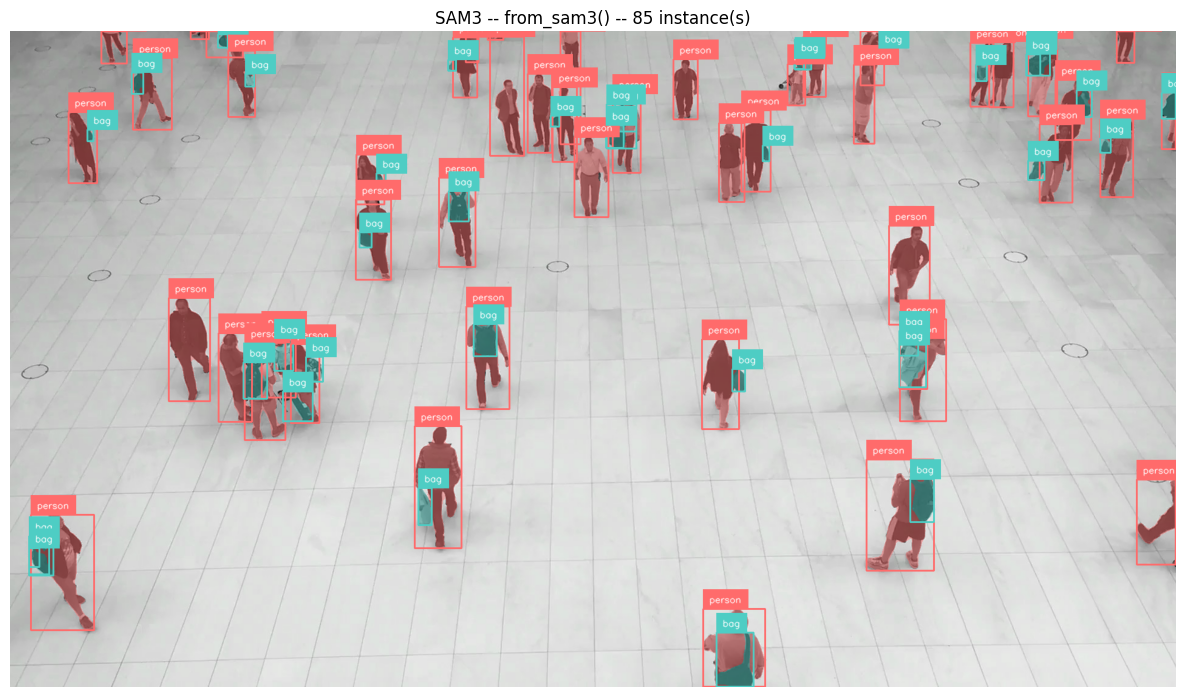

In [12]:
assert sam3_detections is not None and len(sam3_detections) > 0

sam3_labels = (
    [PROMPTS[c] for c in sam3_detections.class_id]
    if sam3_detections.class_id is not None
    else []
)
SAM3_PALETTE = sv.ColorPalette.from_hex(["#ff6b6b", "#4ecdc4"])

annotated_sam3 = image_bgr.copy()
annotated_sam3 = sv.MaskAnnotator(color=SAM3_PALETTE, opacity=0.45).annotate(
    annotated_sam3, sam3_detections
)
annotated_sam3 = sv.BoxAnnotator(color=SAM3_PALETTE, thickness=2).annotate(
    annotated_sam3, sam3_detections
)
annotated_sam3 = sv.LabelAnnotator(
    color=SAM3_PALETTE, text_scale=0.5, text_thickness=1
).annotate(annotated_sam3, sam3_detections, labels=sam3_labels)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated_sam3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"SAM3 -- from_sam3() -- {len(sam3_detections)} instance(s)")
plt.tight_layout()
plt.show()

## Next steps

- [`sv.CompactMask` docs](https://supervision.roboflow.com/develop/detection/compact_mask/)
  -- full API reference: `resize`, `merge`, `with_offset`
- [`sv.Detections.from_sam3` docs](https://supervision.roboflow.com/develop/detection/core/)
  -- PCS and PVS format reference
- [RF-DETR docs](https://github.com/roboflow/rf-detr)
  -- training, export, and deployment
- [Full changelog](https://supervision.roboflow.com/develop/changelog/)
  -- every change in 0.28.0